<a href="https://colab.research.google.com/github/pop756/Quantum_KAN/blob/EMT/Real_backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
""" 
!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt """

' \n!git clone -b EMT https://github.com/pop756/Quantum_KAN.git\n%cd Quantum_KAN\n!pip install -r requirements.txt '

In [2]:
# Initialize your account
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes, EfficientSU2

service = QiskitRuntimeService(
    channel="ibm_quantum",
    instance="ibm-q-skku/skku/skku-students",
    token="06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854",
)
backend = service.backend('ibm_brussels')



In [3]:
from functions.Train_ZNE import update_pulse
import json

with open('./minus_brussels_ecr_data.json','r') as file:
    config_list = json.load(file)
for config in config_list:
    config['amp'] = config['x_amp_3']

update = update_pulse(backend,config_list)


In [19]:
from functions.Train_ZNE import update_pulse
import json

with open('./brussels_ecr_data.json','r') as file:
    config_list_plus = json.load(file)
for config in config_list_plus:
    config['amp'] = config['x_amp_3']
update_plus = update_pulse(backend,config_list)

In [4]:
backend_update = update.update_ecr_real()
#backend_update_plus = update_plus.update_ecr_real()

NameError: name 'update_plus' is not defined

In [ ]:
backend.target['ecr'][tuple(config_list[0]['init'])].calibration

Schedule((0, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.0347179240033617, angle=0.041120823693489815, name='CR90p_d78_u179'), DriveChannel(78), name='CR90p_d78_u179')), (0, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.2639198149085075, angle=-1.0623995056232372, name='CR90p_u179'), ControlChannel(179), name='CR90p_u179')), (600, Play(Drag(duration=120, sigma=30, beta=-0.5739375721020255, amp=0.1900641207813947, angle=0.0, name='Xp_d79'), DriveChannel(79), name='Xp_d79')), (720, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.0347179240033617, angle=-3.1004718298963034, name='CR90m_d78_u179'), DriveChannel(78), name='CR90m_d78_u179')), (720, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.2639198149085075, angle=2.079193147966556, name='CR90m_u179'), ControlChannel(179), name='CR90m_u179')), name="ecr")

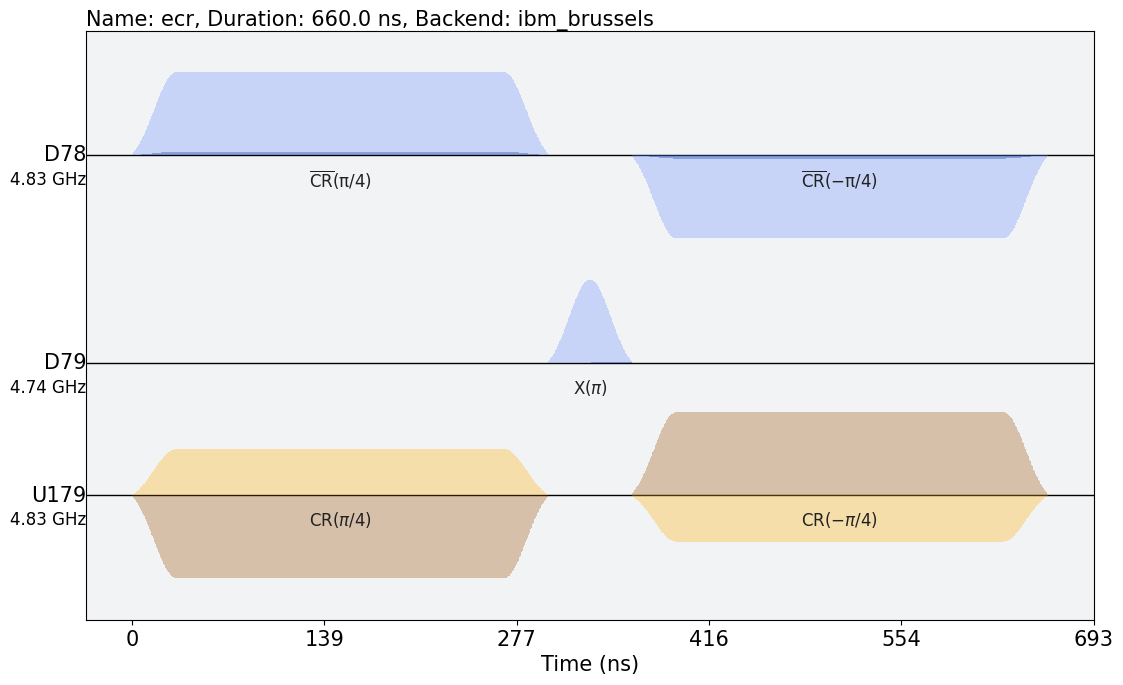

In [ ]:
from qiskit import schedule

backend.target['ecr'][tuple(config_list[0]['init'])].calibration.draw(backend = backend)

In [ ]:
import numpy as np
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
import numpy as np
lengths = np.arange(1, 50, 8)   
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

In [5]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits

## CR 안 건들임
lengths = np.arange(1, 200, 30)     
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

base_runtime_job._start_websocket_client:WARNING:2024-08-09 06:29:01,134: An error occurred while streaming results from the server for job cttakad3zkm0008sc2q0:
Traceback (most recent call last):
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\base_runtime_job.py", line 314, in _start_websocket_client
    self._ws_client.job_results()
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\api\clients\runtime_ws.py", line 70, in job_results
    self.stream(url=url, retries=max_retries, backoff_factor=backoff_factor)
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\api\clients\base_websocket_client.py", line 222, in stream
    raise WebsocketError(error_message)
qiskit_ibm_runtime.api.exceptions.WebsocketError: 'Max retries exceeded: Failed to establish a websocket connection. Error: Traceback (most recent call last):\n  File "c:\\Users\\pop75\\anaconda3\\envs\\EMT\\Lib\\si

In [ ]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits

## CR 안 건들임
lengths = np.arange(1, 50, 8)     
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

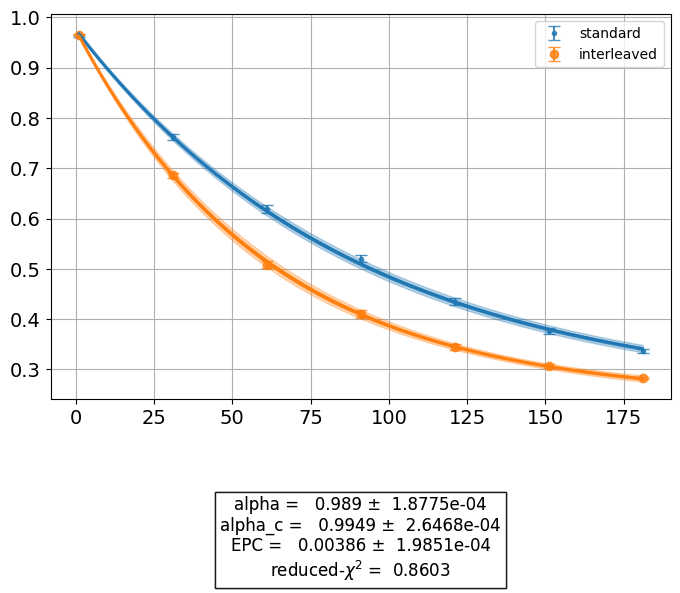

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 25
 - degree of freedom: 10
 - chi-square: 8.602907988527104
 - reduced chi-square: 0.8602907988527104
 - Akaike info crit.: 1.1826013656486873
 - Bayesian info crit.: 3.738830684109721
 - init params:
  * a = 0.7245828504252443
  * alpha = 0.9883805801028508
  * b = 0.25
  * alpha_c = 0.994668278381534
 - fit params:
  * a = 0.731578840514805 ± 0.0040643320847574905
  * alpha = 0.9889505844192527 ± 0.0001877536985148432
  * b = 0.24349580074993726 ± 0.004086847344206282
  * alpha_c = 0.9948529747813637 ± 0.00026467639215353993
 - correlations:
  * (a, b) = -0.9307562284520079
  * (alpha, b) = -0.7524673058348796
  * (b, alpha_c) = -0.6240738376964543
  * (alpha, alpha_c) = 0.17852925884957782
  * (a, alpha_c)

In [8]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


lengths = np.arange(1, 200, 30)     
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

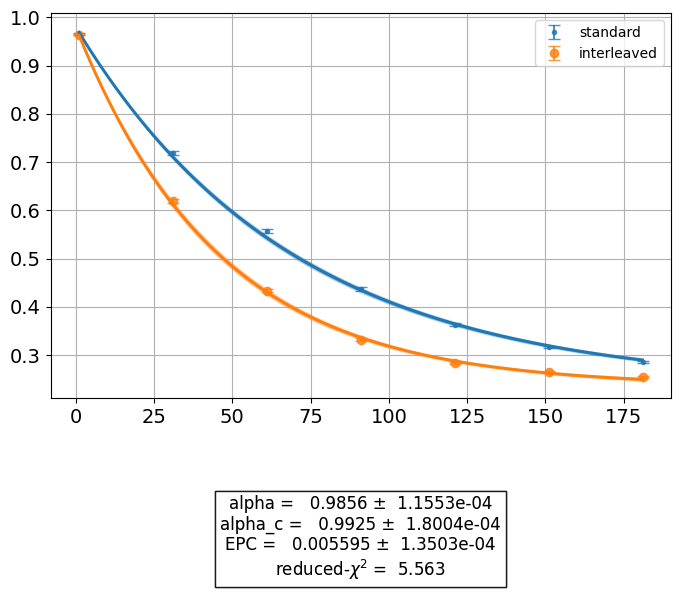

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 10
 - chi-square: 55.63123529350735
 - reduced chi-square: 5.563123529350735
 - Akaike info crit.: 27.31562499654381
 - Bayesian info crit.: 29.871854315004846
 - init params:
  * a = 0.7311657517667205
  * alpha = 0.9834728733174553
  * b = 0.25
  * alpha_c = 0.9882999440431598
 - fit params:
  * a = 0.7441109885987894 ± 0.0016390838783988486
  * alpha = 0.9856210346659138 ± 0.00011553128455083431
  * b = 0.23568327950066265 ± 0.001376300996920184
  * alpha_c = 0.9925403870057804 ± 0.00018004464566076606
 - correlations:
  * (a, b) = -0.7184410657237024
  * (alpha, b) = -0.7070080569685427
  * (b, alpha_c) = -0.535966279053455
  * (alpha, alpha_c) = 0.07985745771190181
  * (a, alpha_c

In [9]:
lengths = np.arange(1, 200, 30)
num_samples = 30
seed = 1010

for config in config_list_plus:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update_plus).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)